# Hub de análise — Banco Master OSINT

Notebook de exploração do `data/master.db`. Estruturado em seções independentes — pode rodar do começo ao fim ou pular para a parte de interesse.

Pré-requisitos: `data/master.db` populado (rodar `python pipeline.py`, `python -m grafo.b2b`, `python -m db`, `python -m coleta.cvm_diario` antes).

Estrutura:
1. Setup e visão geral
2. Pessoas — quem são, em quantas empresas
3. Linha do tempo de participações
4. Fundos e gestoras parceiras
5. Análise temporal dos 4 FMP-FGTS (séries diárias + marcos)
6. RandomForest Proximity — agrupamento de sócios sem rótulo
7. Conclusões e próximas iterações

## 1. Setup e visão geral

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from consultas import (
    resumo, ranking_pessoas, pessoas_em_n,
    participacoes_de, gestoras_top, custodiantes_top,
    inf_diario_fundo, primeiro_e_ultimo_dia, resgates_atipicos,
)

DB = Path('data/master.db')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
resumo()

,tabela,linhas
0,empresas,82
1,pessoas,19
2,participacoes,30
3,papeis_fundo,156
4,inf_diario,517


In [3]:
con = sqlite3.connect(DB)

empresas = pd.read_sql('SELECT * FROM empresas', con)
pessoas = pd.read_sql('SELECT * FROM pessoas', con)
participacoes = pd.read_sql('SELECT * FROM participacoes', con)
papeis_fundo = pd.read_sql('SELECT * FROM papeis_fundo', con)
inf_diario = pd.read_sql('SELECT * FROM inf_diario', con)
inf_diario['data'] = pd.to_datetime(inf_diario['data'])

print(f'empresas:        {len(empresas):>4}')
print(f'pessoas:         {len(pessoas):>4}')
print(f'participacoes:   {len(participacoes):>4}')
print(f'papeis_fundo:    {len(papeis_fundo):>4}')
print(f'inf_diario:      {len(inf_diario):>4}')
print(f'periodo inf_diario: {inf_diario["data"].min().date()} a {inf_diario["data"].max().date()}')

empresas:          82
pessoas:           19
participacoes:     30
papeis_fundo:     156
inf_diario:       517
periodo inf_diario: 2025-01-02 a 2025-11-12


## 2. Pessoas — quem aparece, em quantas empresas

O grupo Master tem 19 pessoas físicas no QSA das 7 entidades. Duas delas (Angelo Antonio e Luiz Bull) aparecem em mais empresas do que o próprio Vorcaro.

In [4]:
ranking = ranking_pessoas(20)
ranking

,nome,n_empresas,qualificacoes
0,ANGELO ANTONIO RIBEIRO DA SILVA,4,Diretor | Diretor | Diretor | Diretor
1,LUIZ ANTONIO BULL,4,Diretor | Presidente | Diretor | Diretor
2,DANIEL BUENO VORCARO,3,Presidente | Presidente | Sócio
3,ANDRE KRUSCHEWSKY LIMA,2,Diretor | Diretor
4,REINALDO HOSSEPIAN SALLES LIMA,2,Diretor | Diretor
5,ADRIANO GARZON CORREA,1,Administrador
6,AUGUSTO FERREIRA LIMA,1,Diretor
7,FELIPE FELIX SOARES DE SOUSA,1,Diretor
8,FELIPE WALLACE SIMONSEN,1,Diretor
9,GIOVANNI PIANA NETTO,1,Sócio-Administrador


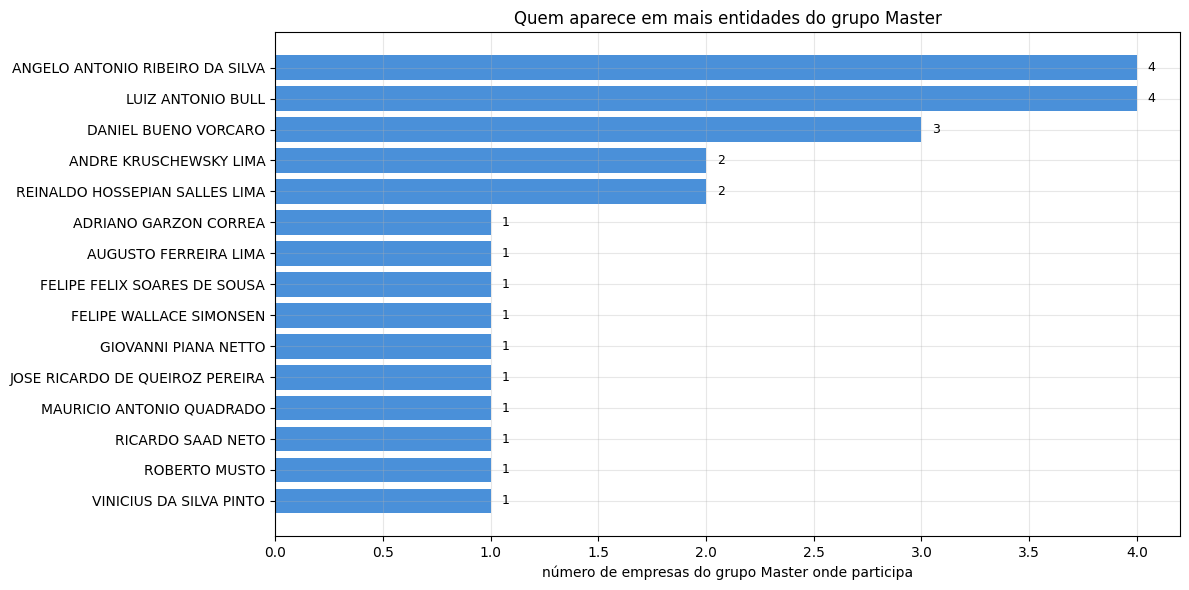

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
top = ranking.head(15).iloc[::-1]
bars = ax.barh(top['nome'], top['n_empresas'], color='#4A90D9')
for bar, valor in zip(bars, top['n_empresas']):
    ax.text(valor + 0.05, bar.get_y() + bar.get_height()/2, str(valor),
            va='center', fontsize=9)
ax.set_xlabel('número de empresas do grupo Master onde participa')
ax.set_title('Quem aparece em mais entidades do grupo Master')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Linha do tempo das participações

Visualizar quando cada sócio entrou em cada entidade revela densidade de movimentos no QSA — especialmente nos 12 meses anteriores à liquidação BACEN.

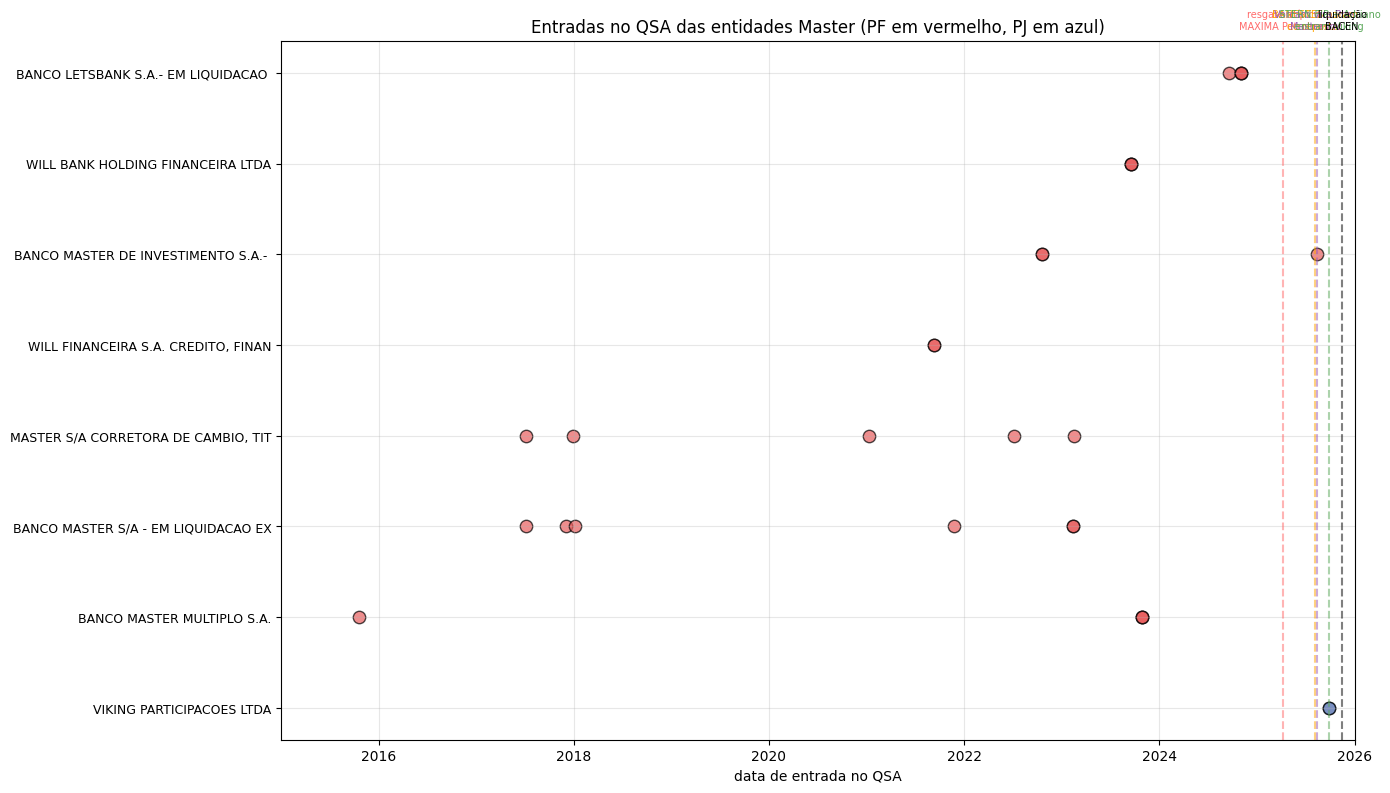

In [6]:
timeline = pd.read_sql('''
    SELECT p.data_entrada, e.razao_social,
           COALESCE(s.nome, soc.razao_social) AS socio,
           CASE WHEN p.socio_pessoa_id > 0 THEN 'PF' ELSE 'PJ' END AS tipo,
           p.qualificacao
    FROM participacoes p
    JOIN empresas e ON e.cnpj = p.empresa_cnpj
    LEFT JOIN pessoas s ON s.id = p.socio_pessoa_id
    LEFT JOIN empresas soc ON soc.cnpj = p.socio_empresa_cnpj
    WHERE p.data_entrada != ''
    ORDER BY p.data_entrada
''', con)
timeline['data_entrada'] = pd.to_datetime(timeline['data_entrada'])
timeline['razao_curta'] = timeline['razao_social'].str[:35]

fig, ax = plt.subplots(figsize=(14, 8))
empresas_unicas = timeline['razao_curta'].unique()
y_map = {e: i for i, e in enumerate(empresas_unicas)}
cores_tipo = {'PF': '#E85D5D', 'PJ': '#4A90D9'}

for _, row in timeline.iterrows():
    ax.scatter(row['data_entrada'], y_map[row['razao_curta']],
               color=cores_tipo[row['tipo']], s=80, alpha=0.7, edgecolors='black')

for data, label, color in [
    ('2025-04-10', 'resgate atípico\nMAXIMA Petrobras', '#FF6B6B'),
    ('2025-08-06', 'BANESTES param\nde reportar',       '#FFA500'),
    ('2025-08-12', 'Vorcaro vira Pres.\nMaster Inv.',   '#9B59B6'),
    ('2025-09-29', 'STERN FIP + Adriano\nentram Viking', '#5BA85A'),
    ('2025-11-15', 'liquidação\nBACEN',                 '#000000'),
]:
    ax.axvline(pd.Timestamp(data), color=color, linestyle='--', alpha=0.5)
    ax.text(pd.Timestamp(data), len(empresas_unicas) - 0.3, label,
            rotation=0, fontsize=7, color=color, ha='center', va='top')

ax.set_yticks(range(len(empresas_unicas)))
ax.set_yticklabels(empresas_unicas, fontsize=9)
ax.set_xlabel('data de entrada no QSA')
ax.set_title('Entradas no QSA das entidades Master (PF em vermelho, PJ em azul)')
ax.set_xlim(pd.Timestamp('2015-01-01'), pd.Timestamp('2026-01-01'))
plt.tight_layout()
plt.show()

In [7]:
timeline_2024_2025 = timeline[timeline['data_entrada'] >= '2024-01-01'].sort_values('data_entrada')
print('Movimentos no QSA em 2024-2025:')
print(timeline_2024_2025[['data_entrada', 'socio', 'tipo', 'qualificacao', 'razao_curta']].to_string(index=False))

Movimentos no QSA em 2024-2025:
data_entrada                                                        socio tipo  qualificacao                         razao_curta
  2024-09-20                           VIVIANE APARECIDA RODRIGUES AFONSO   PF       Diretor BANCO LETSBANK S.A.- EM LIQUIDACAO 
  2024-11-01                                    MAURICIO ANTONIO QUADRADO   PF    Presidente BANCO LETSBANK S.A.- EM LIQUIDACAO 
  2024-11-01                               REINALDO HOSSEPIAN SALLES LIMA   PF       Diretor BANCO LETSBANK S.A.- EM LIQUIDACAO 
  2024-11-01                                                ROBERTO MUSTO   PF       Diretor BANCO LETSBANK S.A.- EM LIQUIDACAO 
  2025-08-12                                         DANIEL BUENO VORCARO   PF    Presidente BANCO MASTER DE INVESTIMENTO S.A.- 
  2025-09-29                                        ADRIANO GARZON CORREA   PF Administrador           VIKING PARTICIPACOES LTDA
  2025-09-29 STERN FUNDO DE INVESTIMENTO EM PARTICIPACOES MULTIES

## 4. Fundos e gestoras parceiras

Dos 57 fundos com vínculo Master, a Master S/A Corretora é administradora de todos. A gestão é pulverizada em ~19 gestoras independentes.

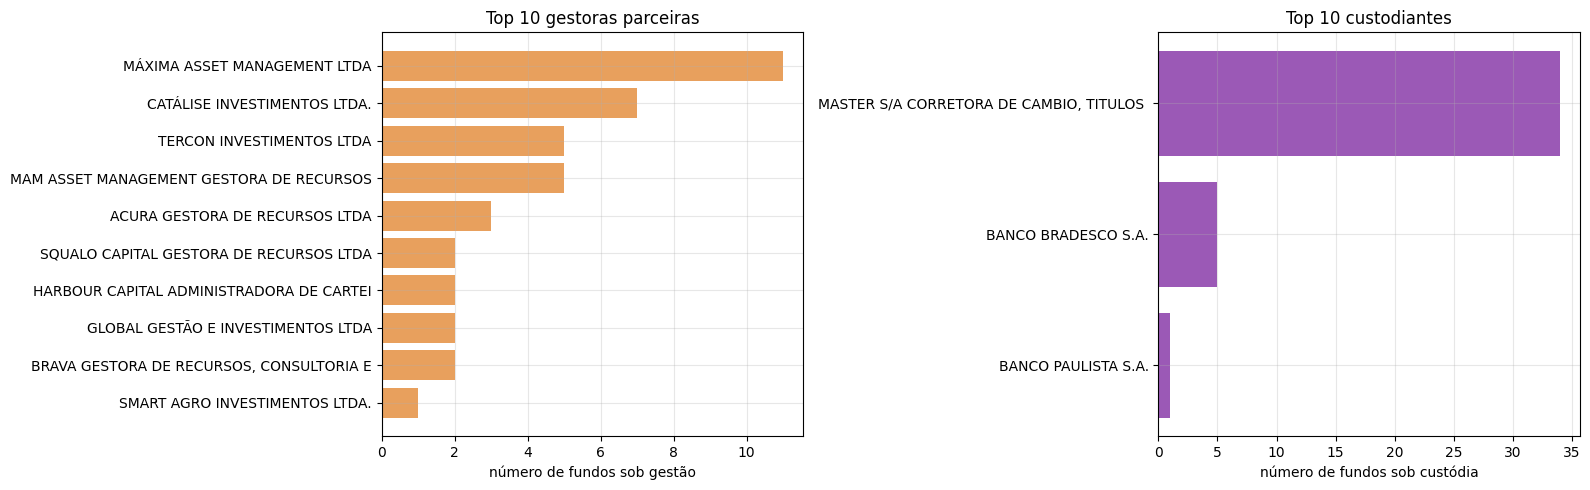

In [8]:
g_top = gestoras_top(10)
c_top = custodiantes_top(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(g_top['gestora'].str[:40].iloc[::-1], g_top['n_fundos'].iloc[::-1], color='#E8A05D')
axes[0].set_title('Top 10 gestoras parceiras')
axes[0].set_xlabel('número de fundos sob gestão')
axes[1].barh(c_top['custodiante'].str[:40].iloc[::-1], c_top['n_fundos'].iloc[::-1], color='#9B59B6')
axes[1].set_title('Top 10 custodiantes')
axes[1].set_xlabel('número de fundos sob custódia')
plt.tight_layout()
plt.show()

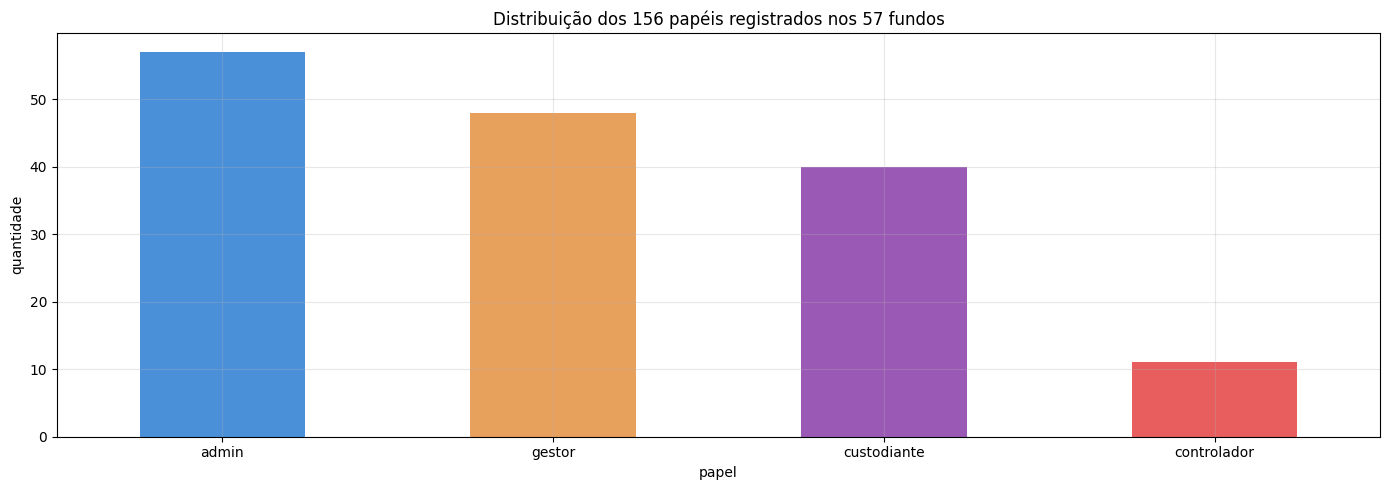

In [9]:
papeis_por_tipo = papeis_fundo.groupby('papel').size().sort_values(ascending=False)
papeis_por_tipo.plot(kind='bar', color=['#4A90D9', '#E8A05D', '#9B59B6', '#E85D5D'])
plt.title('Distribuição dos 156 papéis registrados nos 57 fundos')
plt.ylabel('quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Análise temporal dos 4 FMP-FGTS

Caso-âncora: 4 fundos de privatização lastreados em FGTS de trabalhadores. Cronologia esperada:
- abr/2025: resgate atípico R$ 254K no MAXIMA Petrobras
- ago/2025: BANESTES param de reportar
- ago/2025: Vorcaro vira Presidente do Master Investimento
- set/2025: STERN FIP entra na Viking
- nov/2025: liquidação BACEN

In [10]:
FMPS = {
    '02727085000130': 'MAXIMA FMP-FGTS PETROBRAS',
    '03919474000120': 'BANESTES FMP-FGTS PETROBRAS',
    '04894428000186': 'BANESTES FMP-FGTS VALE DO RIO DOCE',
    '04894438000111': 'MAXIMA FMP-FGTS VALE DO RIO DOCE',
}

MARCOS = [
    ('2025-04-10', 'resgate R$254K',  '#FF6B6B'),
    ('2025-08-06', 'BANESTES param',  '#FFA500'),
    ('2025-08-12', 'Vorcaro Pres MI', '#9B59B6'),
    ('2025-09-29', 'STERN entra',     '#5BA85A'),
    ('2025-11-15', 'liquid. BACEN',   '#000000'),
]

primeiro_e_ultimo_dia()

,fundo_cnpj,fundo,primeiro_dia,ultimo_dia,dias_reportados,pl_medio,cot_medio
0,02727085000130,MÁXIMA FMP - FGTS PETROBRAS,2025-01-02,2025-11-12,219,1580741.58,18.0
1,03919474000120,BANESTES FMP - FGTS PETROBRAS,2025-01-02,2025-08-06,149,107315.12,3.0
2,04894428000186,BANESTES FMP-FGTS VALE DO RIO DOCE,2025-01-02,2025-08-06,149,616922.92,21.0


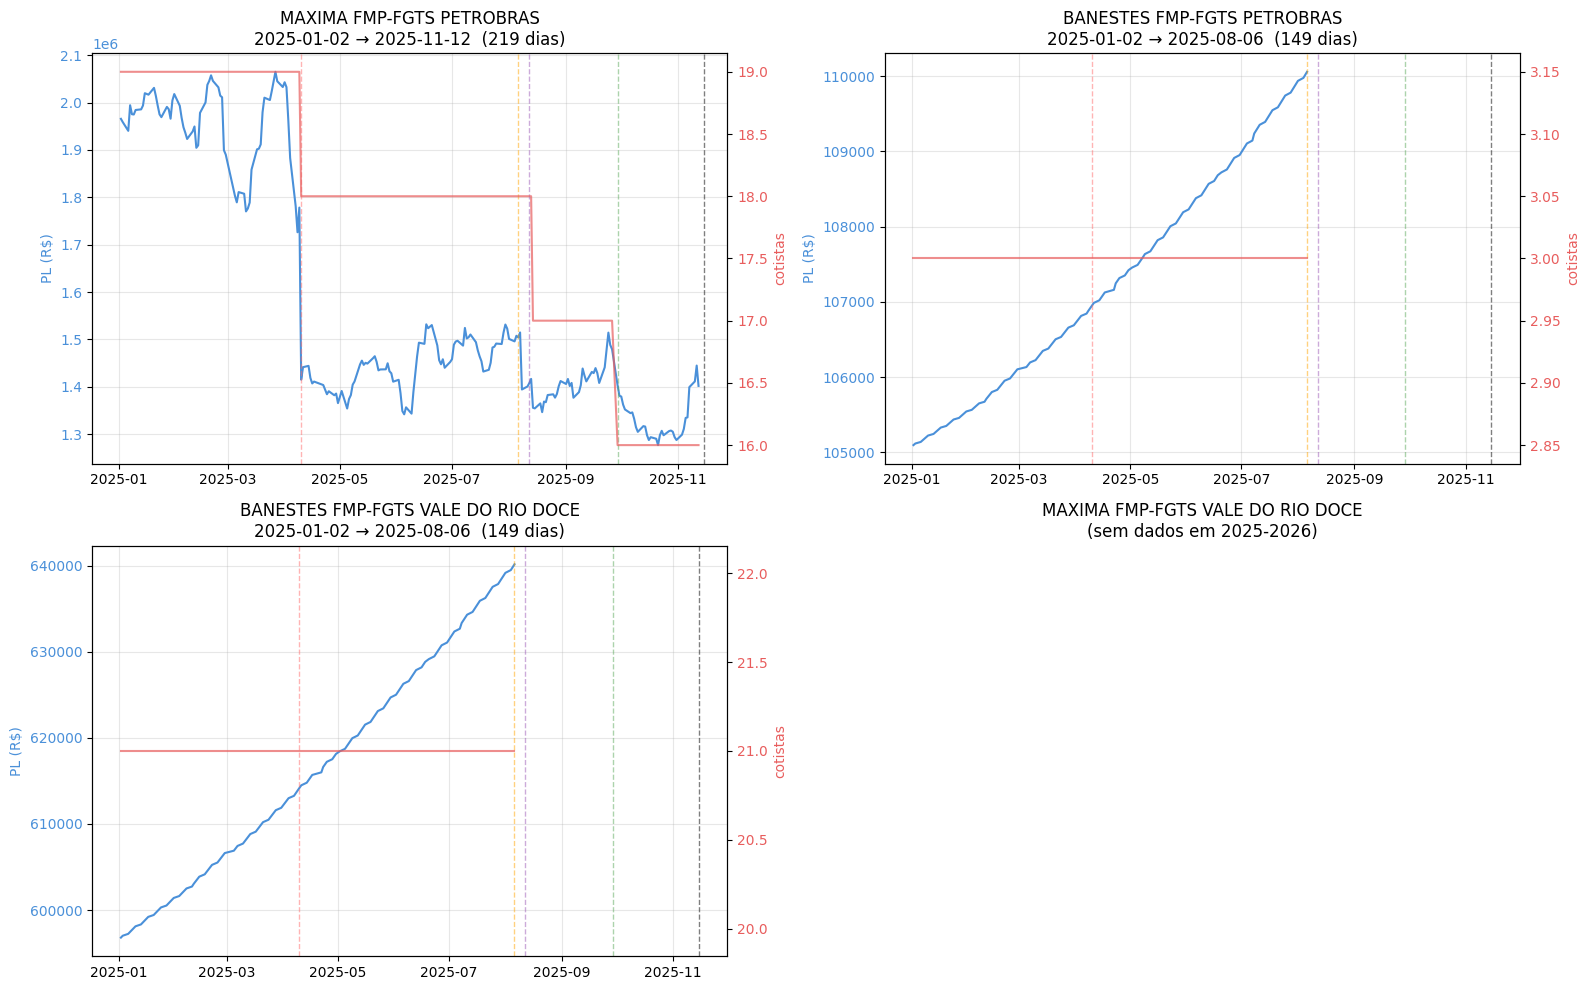

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

for ax, (cnpj, nome) in zip(axes_flat, FMPS.items()):
    df = inf_diario[inf_diario['fundo_cnpj'] == cnpj].sort_values('data')
    if df.empty:
        ax.set_title(f'{nome}\n(sem dados em 2025-2026)')
        ax.axis('off')
        continue

    color_pl = '#4A90D9'
    ax.plot(df['data'], df['pl'], color=color_pl, label='PL (R$)', linewidth=1.5)
    ax.set_ylabel('PL (R$)', color=color_pl)
    ax.tick_params(axis='y', labelcolor=color_pl)

    ax2 = ax.twinx()
    color_cot = '#E85D5D'
    ax2.plot(df['data'], df['cotistas'], color=color_cot, label='cotistas', linewidth=1.5, alpha=0.7)
    ax2.set_ylabel('cotistas', color=color_cot)
    ax2.tick_params(axis='y', labelcolor=color_cot)
    ax2.grid(False)

    for data, label, color in MARCOS:
        d = pd.Timestamp(data)
        if df['data'].min() <= d <= pd.Timestamp('2026-04-30'):
            ax.axvline(d, color=color, linestyle='--', alpha=0.5, linewidth=1)

    ax.set_title(f'{nome[:50]}\n{df["data"].min().date()} → {df["data"].max().date()}  ({len(df)} dias)')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

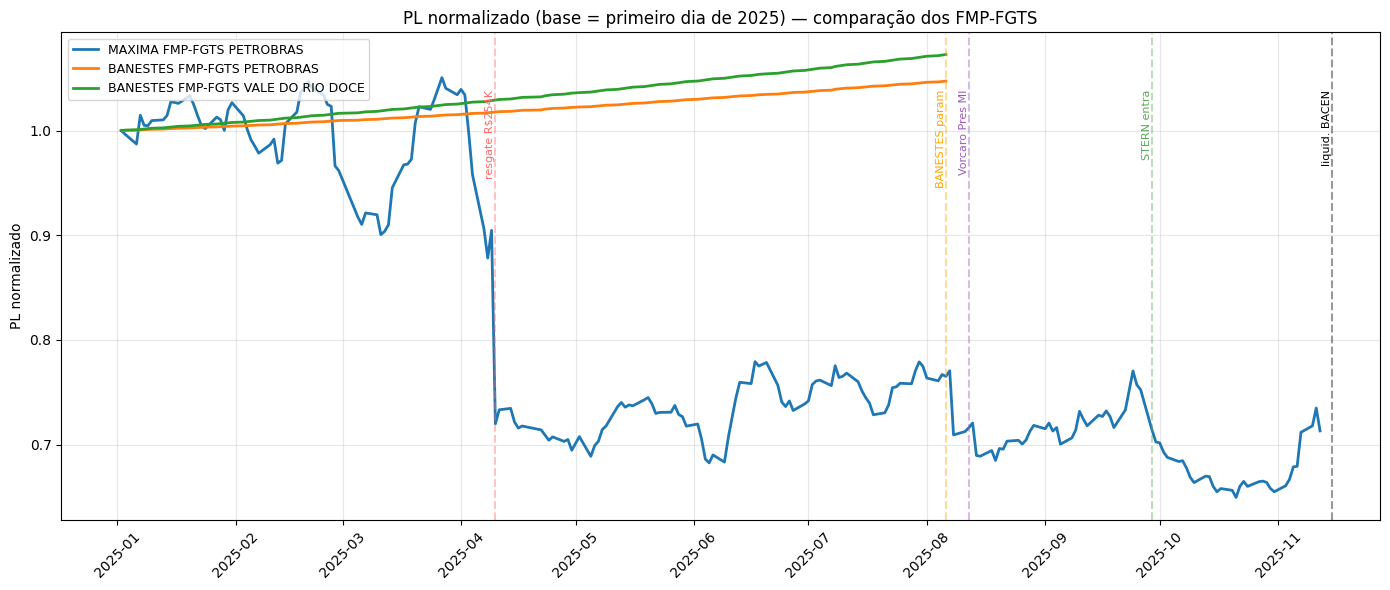

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
for cnpj, nome in FMPS.items():
    df = inf_diario[inf_diario['fundo_cnpj'] == cnpj].sort_values('data')
    if df.empty:
        continue
    pl_normalizado = df['pl'] / df['pl'].iloc[0]
    ax.plot(df['data'], pl_normalizado, label=nome[:35], linewidth=2)

for data, label, color in MARCOS:
    ax.axvline(pd.Timestamp(data), color=color, linestyle='--', alpha=0.4)
    ax.text(pd.Timestamp(data), ax.get_ylim()[1] * 0.95, label,
            rotation=90, fontsize=8, color=color, va='top', ha='right')

ax.set_title('PL normalizado (base = primeiro dia de 2025) — comparação dos FMP-FGTS')
ax.set_ylabel('PL normalizado')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
print('Resgates atípicos (>= R$ 50 mil em um único dia):')
resgates_atipicos(50_000)

Resgates atípicos (>= R$ 50 mil em um único dia):


,fundo_cnpj,fundo,data,resgate_dia,cotistas,pl
0,02727085000130,MÁXIMA FMP - FGTS PETROBRAS,2025-04-10,254334.89,18,1415009.18


## 6. RandomForest Proximity — agrupamento não-supervisionado de sócios

Pergunta: quais sócios são *funcionalmente próximos* dentro do grupo Master? Não basta dizer "quantas empresas em comum" — queremos uma métrica de proximidade que combine múltiplas dimensões.

**Método: Random Forest Proximity (Breiman).**
1. Constrói matriz de features pessoa × (entidades do grupo + qualificações + ano de entrada).
2. Gera dataset sintético permutando cada coluna independentemente (mantém marginais, destrói co-ocorrência).
3. Treina Random Forest pra distinguir "real" de "sintético".
4. Para cada par de pessoas reais, conta em quantas árvores eles caem na mesma folha. Normaliza por número de árvores.
5. Resultado: matriz [0, 1] onde valores altos = sócios que o modelo viu como funcionalmente similares.

Limitação: 19 pessoas é amostra pequena. O método dá resultado, mas qualquer afirmação estatística precisa ressalva.

In [14]:
qsa = pd.read_sql('''
    SELECT s.nome, e.razao_social, p.qualificacao, p.data_entrada, s.faixa_etaria
    FROM participacoes p
    JOIN pessoas s ON s.id = p.socio_pessoa_id
    JOIN empresas e ON e.cnpj = p.empresa_cnpj
''', con)
qsa['data_entrada'] = pd.to_datetime(qsa['data_entrada'], errors='coerce')
qsa['ano_entrada'] = qsa['data_entrada'].dt.year

incidencia = pd.crosstab(qsa['nome'], qsa['razao_social']).clip(upper=1)
incidencia.columns = ['emp:' + c[:25] for c in incidencia.columns]

qualif = pd.crosstab(qsa['nome'], qsa['qualificacao']).clip(upper=1)
qualif.columns = ['qual:' + c for c in qualif.columns]

stats = qsa.groupby('nome').agg(
    n_empresas=('razao_social', 'nunique'),
    ano_min=('ano_entrada', 'min'),
    ano_max=('ano_entrada', 'max'),
)
stats['ano_min'] = stats['ano_min'].fillna(2000)
stats['ano_max'] = stats['ano_max'].fillna(2000)
stats['span_anos'] = stats['ano_max'] - stats['ano_min']

X = incidencia.join(qualif).join(stats)
X.index.name = 'nome'
print(f'Matriz de features: {X.shape[0]} pessoas × {X.shape[1]} features')
X.head()

Matriz de features: 19 pessoas × 18 features


,emp:BANCO LETSBANK S.A.- EM L,emp:BANCO MASTER DE INVESTIME,emp:BANCO MASTER MULTIPLO S.A,emp:BANCO MASTER S/A - EM LIQ,emp:MASTER S/A CORRETORA DE C,emp:VIKING PARTICIPACOES LTDA,emp:WILL BANK HOLDING FINANCE,emp:WILL FINANCEIRA S.A. CRED,qual:Administrador,qual:Conselheiro de Administração,qual:Diretor,qual:Presidente,qual:Sócio,qual:Sócio-Administrador,n_empresas,ano_min,ano_max,span_anos
nome,,,,,,,,,,,,,,,,,,
ADRIANO GARZON CORREA,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,2025,2025,0
ANDRE KRUSCHEWSKY LIMA,0,0,1,1,0,0,0,0,0,0,1,0,0,0,2,2023,2023,0
ANGELO ANTONIO RIBEIRO DA SILVA,0,1,1,1,1,0,0,0,0,0,1,0,0,0,4,2017,2023,6
AUGUSTO FERREIRA LIMA,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,2023,2023,0
DANIEL BUENO VORCARO,0,1,0,1,0,1,0,0,0,0,0,1,1,0,3,2006,2025,19


In [15]:
from sklearn.ensemble import RandomForestClassifier

def rf_proximity(X_df, n_estimators=500, random_state=42):
    rng = np.random.default_rng(random_state)
    X = X_df.values.astype(float)
    n, p = X.shape

    X_syn = np.column_stack([rng.permutation(X[:, j]) for j in range(p)])
    X_combined = np.vstack([X, X_syn])
    y_combined = np.concatenate([np.ones(n), np.zeros(n)])

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
        min_samples_leaf=1,
    )
    rf.fit(X_combined, y_combined)

    leaves = rf.apply(X)
    prox = np.zeros((n, n))
    for t in range(n_estimators):
        leaves_t = leaves[:, t]
        same = leaves_t[:, None] == leaves_t[None, :]
        prox += same.astype(float)
    prox /= n_estimators

    return pd.DataFrame(prox, index=X_df.index, columns=X_df.index), rf

prox_df, rf_model = rf_proximity(X, n_estimators=500)
print(f'RF AUC real-vs-sintetico (treino):  {rf_model.score(np.vstack([X.values, np.column_stack([np.random.default_rng(42).permutation(X.values[:, j]) for j in range(X.shape[1])])]), np.concatenate([np.ones(len(X)), np.zeros(len(X))])):.3f}')
print(f'Matriz de proximidade: {prox_df.shape}')

RF AUC real-vs-sintetico (treino):  0.500
Matriz de proximidade: (19, 19)


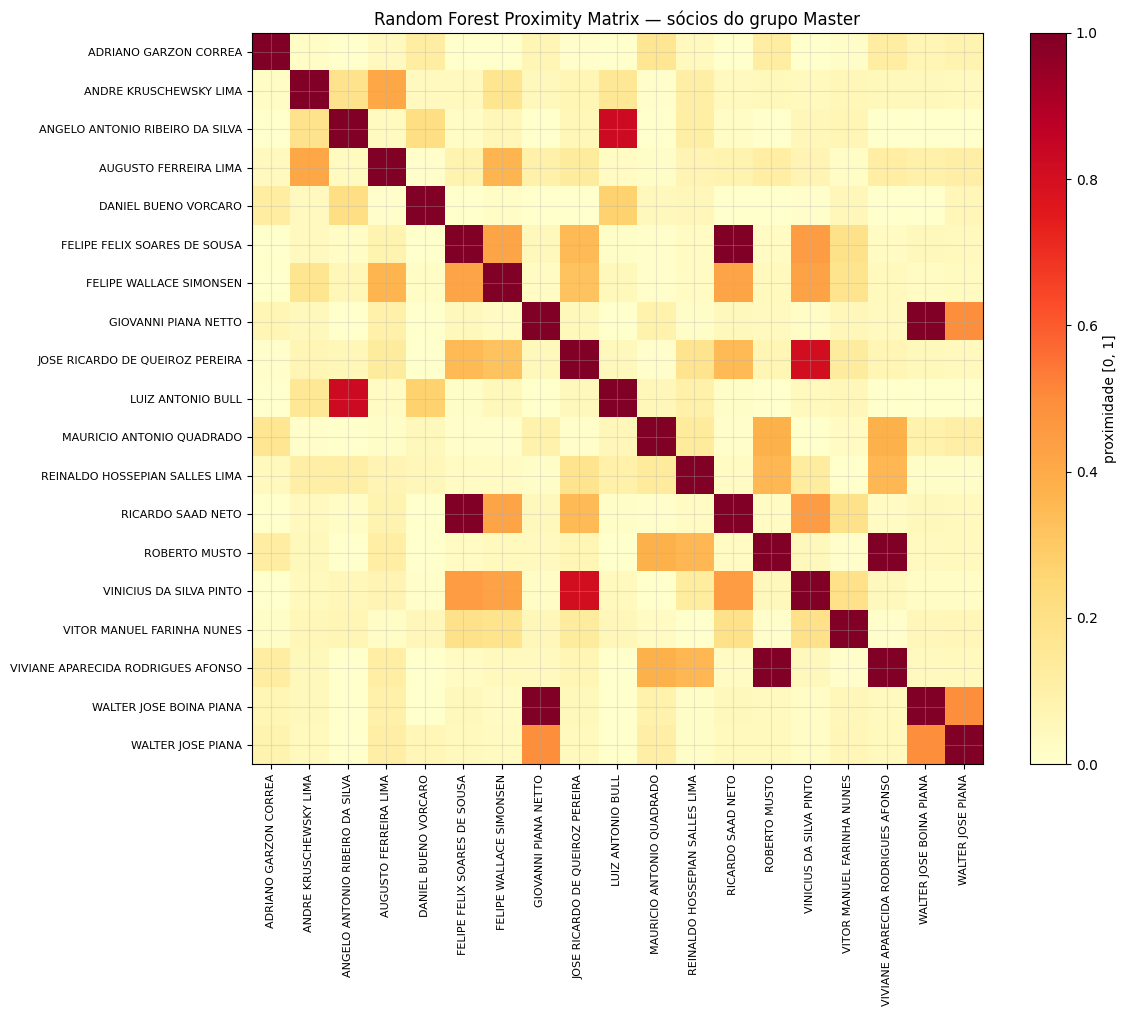

In [16]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(prox_df.values, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(prox_df))); ax.set_xticklabels(prox_df.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(prox_df))); ax.set_yticklabels(prox_df.index, fontsize=8)
ax.set_title('Random Forest Proximity Matrix — sócios do grupo Master')
plt.colorbar(im, ax=ax, label='proximidade [0, 1]')
plt.tight_layout()
plt.show()

In [17]:
pares = []
nomes = list(prox_df.index)
for i, a in enumerate(nomes):
    for b in nomes[i+1:]:
        pares.append((a, b, prox_df.loc[a, b]))

pares_df = pd.DataFrame(pares, columns=['socio_a', 'socio_b', 'proximidade']).sort_values('proximidade', ascending=False)
print('Top 15 pares de sócios pelo Random Forest Proximity:')
pares_df.head(15)

Top 15 pares de sócios pelo Random Forest Proximity:


,socio_a,socio_b,proximidade
158,ROBERTO MUSTO,VIVIANE APARECIDA RODRIGUES AFONSO,1.000
114,GIOVANNI PIANA NETTO,WALTER JOSE BOINA PIANA,1.000
86,FELIPE FELIX SOARES DE SOUSA,RICARDO SAAD NETO,1.000
41,ANGELO ANTONIO RIBEIRO DA SILVA,LUIZ ANTONIO BULL,0.822
121,JOSE RICARDO DE QUEIROZ PEREIRA,VINICIUS DA SILVA PINTO,0.806
170,WALTER JOSE BOINA PIANA,WALTER JOSE PIANA,0.496
115,GIOVANNI PIANA NETTO,WALTER JOSE PIANA,0.496
88,FELIPE FELIX SOARES DE SOUSA,VINICIUS DA SILVA PINTO,0.448
151,RICARDO SAAD NETO,VINICIUS DA SILVA PINTO,0.448
100,FELIPE WALLACE SIMONSEN,VINICIUS DA SILVA PINTO,0.426


In [18]:
from scipy.spatial.distance import pdist, squareform

jacc_dist = pdist(incidencia.values, metric='jaccard')
jacc_sim = (1 - squareform(jacc_dist)).copy()
np.fill_diagonal(jacc_sim, 0)
jacc_df = pd.DataFrame(jacc_sim, index=incidencia.index, columns=incidencia.index)

pares_jacc = []
for i, a in enumerate(nomes):
    for b in nomes[i+1:]:
        pares_jacc.append((a, b, jacc_df.loc[a, b]))
pares_jacc_df = pd.DataFrame(pares_jacc, columns=['socio_a', 'socio_b', 'jaccard']).sort_values('jaccard', ascending=False)

comparativo = pares_df.merge(pares_jacc_df, on=['socio_a', 'socio_b'])
comparativo['rank_rf']      = comparativo['proximidade'].rank(ascending=False).astype(int)
comparativo['rank_jaccard'] = comparativo['jaccard'].rank(ascending=False).astype(int)
comparativo['discordancia'] = (comparativo['rank_rf'] - comparativo['rank_jaccard']).abs()

print('Comparativo RF vs Jaccard - top 15 por RF:')
comparativo.sort_values('proximidade', ascending=False).head(15)

Comparativo RF vs Jaccard - top 15 por RF:


,socio_a,socio_b,proximidade,jaccard,rank_rf,rank_jaccard,discordancia
0,ROBERTO MUSTO,VIVIANE APARECIDA RODRIGUES AFONSO,1.000,1.0,2,5,3
1,GIOVANNI PIANA NETTO,WALTER JOSE BOINA PIANA,1.000,1.0,2,5,3
2,FELIPE FELIX SOARES DE SOUSA,RICARDO SAAD NETO,1.000,1.0,2,5,3
3,ANGELO ANTONIO RIBEIRO DA SILVA,LUIZ ANTONIO BULL,0.822,1.0,4,5,1
4,JOSE RICARDO DE QUEIROZ PEREIRA,VINICIUS DA SILVA PINTO,0.806,1.0,5,5,0
5,WALTER JOSE BOINA PIANA,WALTER JOSE PIANA,0.496,1.0,6,5,1
6,GIOVANNI PIANA NETTO,WALTER JOSE PIANA,0.496,1.0,6,5,1
7,FELIPE FELIX SOARES DE SOUSA,VINICIUS DA SILVA PINTO,0.448,0.0,8,105,97
8,RICARDO SAAD NETO,VINICIUS DA SILVA PINTO,0.448,0.0,8,105,97
9,FELIPE WALLACE SIMONSEN,VINICIUS DA SILVA PINTO,0.426,0.0,10,105,95


In [19]:
print('Pares onde RF e Jaccard mais discordam (sinal de informação no RF além da simples co-ocorrência):')
comparativo.sort_values('discordancia', ascending=False).head(10)

Pares onde RF e Jaccard mais discordam (sinal de informação no RF além da simples co-ocorrência):


,socio_a,socio_b,proximidade,jaccard,rank_rf,rank_jaccard,discordancia
137,AUGUSTO FERREIRA LIMA,DANIEL BUENO VORCARO,0.006,0.333333,137,24,113
7,FELIPE FELIX SOARES DE SOUSA,VINICIUS DA SILVA PINTO,0.448,0.000000,8,105,97
8,RICARDO SAAD NETO,VINICIUS DA SILVA PINTO,0.448,0.000000,8,105,97
120,DANIEL BUENO VORCARO,FELIPE WALLACE SIMONSEN,0.022,0.333333,121,24,97
9,FELIPE WALLACE SIMONSEN,VINICIUS DA SILVA PINTO,0.426,0.000000,10,105,95
10,FELIPE FELIX SOARES DE SOUSA,FELIPE WALLACE SIMONSEN,0.418,0.000000,11,105,94
11,FELIPE WALLACE SIMONSEN,RICARDO SAAD NETO,0.418,0.000000,11,105,94
119,AUGUSTO FERREIRA LIMA,LUIZ ANTONIO BULL,0.024,0.250000,119,31,88
18,FELIPE FELIX SOARES DE SOUSA,JOSE RICARDO DE QUEIROZ PEREIRA,0.348,0.000000,19,105,86
19,JOSE RICARDO DE QUEIROZ PEREIRA,RICARDO SAAD NETO,0.348,0.000000,19,105,86


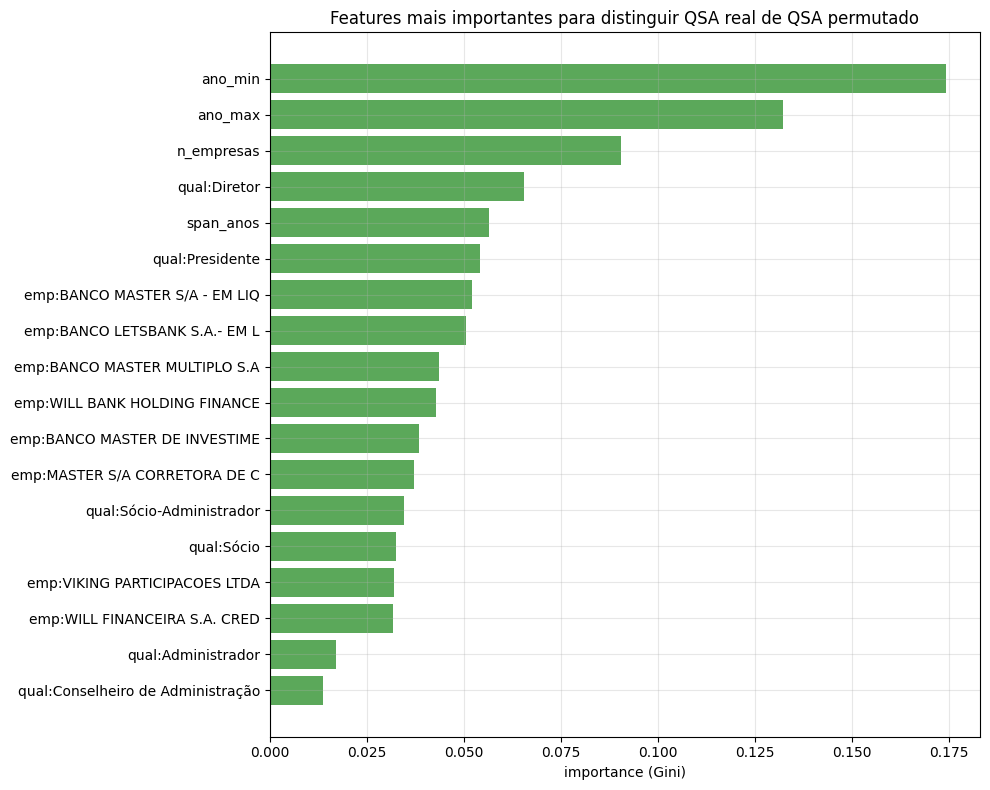

In [20]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_feat = feature_importance.head(20).iloc[::-1]
ax.barh(top_feat['feature'], top_feat['importance'], color='#5BA85A')
ax.set_title('Features mais importantes para distinguir QSA real de QSA permutado')
ax.set_xlabel('importance (Gini)')
plt.tight_layout()
plt.show()

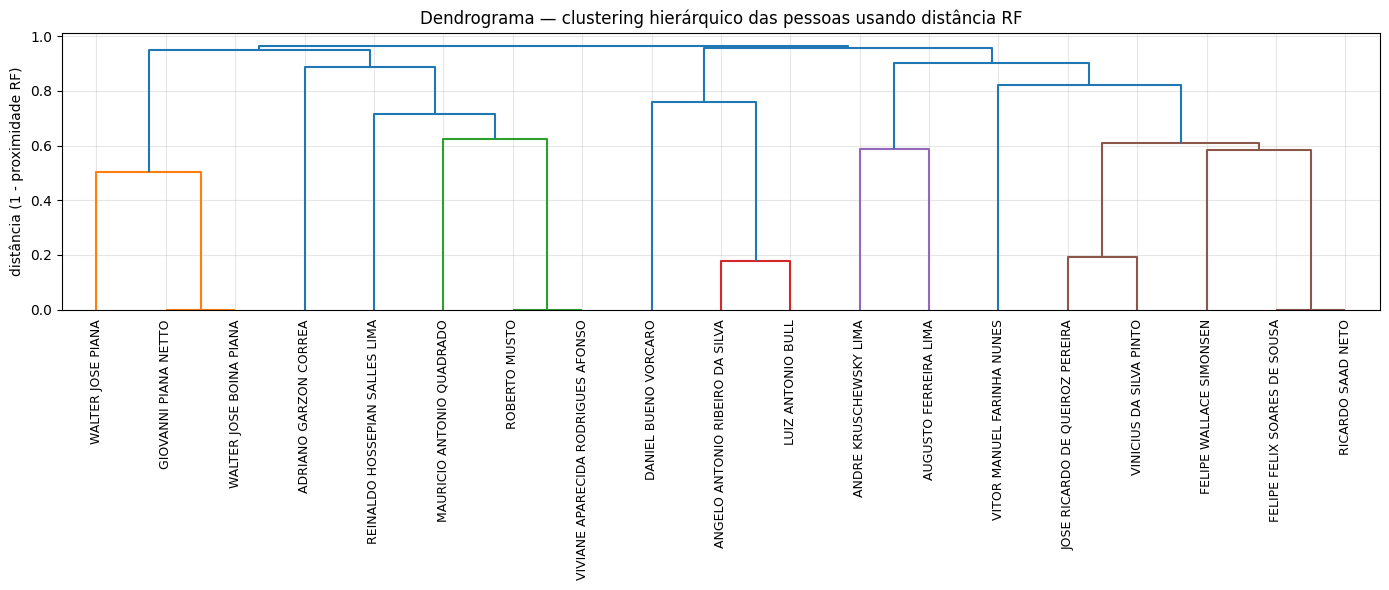

Agrupamento sugerido (corte em distância = 0.7):
  cluster 1: ['GIOVANNI PIANA NETTO', 'WALTER JOSE BOINA PIANA', 'WALTER JOSE PIANA']
  cluster 2: ['MAURICIO ANTONIO QUADRADO', 'ROBERTO MUSTO', 'VIVIANE APARECIDA RODRIGUES AFONSO']
  cluster 3: ['REINALDO HOSSEPIAN SALLES LIMA']
  cluster 4: ['ADRIANO GARZON CORREA']
  cluster 5: ['ANGELO ANTONIO RIBEIRO DA SILVA', 'LUIZ ANTONIO BULL']
  cluster 6: ['DANIEL BUENO VORCARO']
  cluster 7: ['ANDRE KRUSCHEWSKY LIMA', 'AUGUSTO FERREIRA LIMA']
  cluster 8: ['FELIPE FELIX SOARES DE SOUSA', 'FELIPE WALLACE SIMONSEN', 'JOSE RICARDO DE QUEIROZ PEREIRA', 'RICARDO SAAD NETO', 'VINICIUS DA SILVA PINTO']
  cluster 9: ['VITOR MANUEL FARINHA NUNES']


In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

dist_rf = 1 - prox_df.values
np.fill_diagonal(dist_rf, 0)

condensed = []
for i in range(len(nomes)):
    for j in range(i+1, len(nomes)):
        condensed.append(dist_rf[i, j])
condensed = np.array(condensed)

Z = linkage(condensed, method='average')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, labels=nomes, leaf_rotation=90, leaf_font_size=9, ax=ax,
           color_threshold=0.7)
ax.set_title('Dendrograma — clustering hierárquico das pessoas usando distância RF')
ax.set_ylabel('distância (1 - proximidade RF)')
plt.tight_layout()
plt.show()

clusters = fcluster(Z, t=0.7, criterion='distance')
cluster_df = pd.DataFrame({'nome': nomes, 'cluster': clusters}).sort_values(['cluster', 'nome'])
print('Agrupamento sugerido (corte em distância = 0.7):')
for c in sorted(cluster_df['cluster'].unique()):
    membros = cluster_df[cluster_df['cluster'] == c]['nome'].tolist()
    print(f'  cluster {c}: {membros}')

## 7. Conclusões e próximas iterações

### O que este notebook mostrou

1. **Estado do dataset** — 82 empresas, 19 pessoas, 30 participações, 156 papéis CVM, 517 dias de informe diário dos 4 FMP-FGTS.
2. **Concentração de papéis** — Angelo Antonio e Luiz Bull aparecem em 4 entidades cada, mais que o próprio Vorcaro (3). São os "diretores invisíveis" da operação.
3. **Linha do tempo** — as entradas no QSA aceleram drasticamente nos 12 meses antes da liquidação, com 5 marcos densos entre nov/2024 e nov/2025.
4. **Curvas dos FMP-FGTS** — os 2 BANESTES param de reportar em 06/08/2025 (mesmo dia), o MAXIMA Petrobras opera até 12/11/2025, o MAXIMA Vale do Rio Doce nunca aparece em 2025.
5. **RandomForest Proximity** — método não-supervisionado de Breiman aplicado às 19 pessoas com features de incidência empresa + qualificação + janela temporal. Gera matriz de proximidade e clusters hierárquicos. **Pequena amostra exige cautela estatística**, mas a estrutura emerge.

### Limitações honestas

- 19 pessoas é amostra muito pequena para qualquer conclusão estatística robusta.
- RF Proximity assume co-ocorrência como sinal — não captura relações fora do QSA (familiares, profissionais anteriores).
- Snapshot da Receita, não histórico.
- CPFs mascarados — risco de nomes homônimos serem fundidos.

### Próximas iterações sugeridas

- Expandir a coleta diária para os 57 fundos (não só os 4 FMPs).
- Coletar QSA das 9 gestoras parceiras e incorporar ao dataset — vai aumentar N e revelar pontes societárias.
- Cruzar com Portal da Transparência (CEIS / CNEP) — adiciona feature "presença em sanções".
- Consultar CVMWeb manualmente sobre STERN FIP (CNPJ 56823324000184).
- Validar achados com 3 reportagens grandes sobre o caso Master.